# SQL e inferência: quem usa a conta?

> **Dados integralmente sintéticos.** Execute `python -m src.pipeline` antes deste notebook.

Aberturas de conta não equivalem a engajamento. Medimos DAU, MAU, ticket e retenção por coorte de abertura. Cada conta é a unidade dos testes, reduzindo pseudorreplicação.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image
from src.config import DATA, REPORTS, FIGURES


## Consultas SQL auditáveis

In [2]:
from src.eda import QUERIES, run
for name, query in QUERIES.items():
    print(name, query)
results = run()
display(results)

dau SELECT date, count(DISTINCT account_id) AS dau FROM transactions GROUP BY 1 ORDER BY 1
mau SELECT date_trunc('month', date) AS month, count(DISTINCT account_id) AS mau FROM transactions GROUP BY 1 ORDER BY 1
ticket SELECT category, count(*) AS transactions, avg(amount) AS average_ticket FROM transactions GROUP BY 1 ORDER BY 1
retention 
        WITH cohorts AS (
          SELECT account_id, date_trunc('month', opened_at) AS cohort FROM accounts
        ), activity AS (
          SELECT DISTINCT account_id, date_trunc('month', date) AS month FROM transactions
        ), sizes AS (SELECT cohort, count(*) AS cohort_size FROM cohorts GROUP BY 1)
        SELECT c.cohort, a.month, date_diff('month', c.cohort, a.month) AS age_months,
               count(*) AS active_accounts, max(s.cohort_size) AS cohort_size,
               count(*)::DOUBLE / max(s.cohort_size) AS retention
        FROM cohorts c JOIN activity a USING(account_id) JOIN sizes s USING(cohort)
        GROUP BY 1, 2 ORDER BY

{'account_mean_ticket': 89.24864176630585,
 'ticket_ci95': [np.float64(89.06066651005064), np.float64(89.43661702256107)],
 'welch_pvalue': 0.09061348080044482,
 'chi2_pvalue': 0.7414361308507182,
 'inactive_share': 0.3406}

## Retenção: proporção da coorte ativa em cada mês observado

In [3]:
retention = pd.read_csv(REPORTS / 'sql_retention.csv')
display(retention.pivot(index='cohort', columns='age_months', values='retention').round(3))

age_months,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.944,1.0,1.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.935,0.903,0.875,0.845,0.817,0.788,0.764,0.730,0.700,0.675
2024-02-01,0.968,1.0,1.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.909,0.892,0.869,0.838,0.804,0.766,0.730,0.688,0.663,NaN
2024-03-01,0.934,1.0,1.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.857,0.831,0.797,0.773,0.751,0.713,0.677,0.651,NaN,NaN
2024-04-01,0.964,1.0,1.0,1.000,1.000,1.000,1.000,1.000,1.000,0.990,...,0.820,0.784,0.760,0.731,0.695,0.667,0.646,NaN,NaN,NaN
2024-05-01,0.974,1.0,1.0,1.000,1.000,1.000,1.000,1.000,0.974,0.941,...,0.793,0.765,0.730,0.690,0.662,0.624,NaN,NaN,NaN,NaN
2024-06-01,0.965,1.0,1.0,1.000,1.000,1.000,1.000,0.982,0.959,0.937,...,0.758,0.732,0.697,0.675,0.654,NaN,NaN,NaN,NaN,NaN
2024-07-01,0.963,1.0,1.0,1.000,1.000,1.000,0.991,0.963,0.934,0.895,...,0.757,0.732,0.711,0.689,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,0.971,1.0,1.0,1.000,1.000,0.978,0.964,0.927,0.900,0.863,...,0.734,0.712,0.690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,0.957,1.0,1.0,1.000,0.989,0.970,0.942,0.925,0.899,0.866,...,0.688,0.666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## MAU, DAU e ticket

,month,mau
19,2025-08-01,3890
20,2025-09-01,3754
21,2025-10-01,3576
22,2025-11-01,3428
23,2025-12-01,3303


,date,dau
726,2025-12-27,1431
727,2025-12-28,1533
728,2025-12-29,1978
729,2025-12-30,2049
730,2025-12-31,2061


,category,transactions,average_ticket
0,PIX,973662,89.351409
1,boleto,317207,89.056165
2,cartao,719267,89.268728
3,saque,105420,89.190039


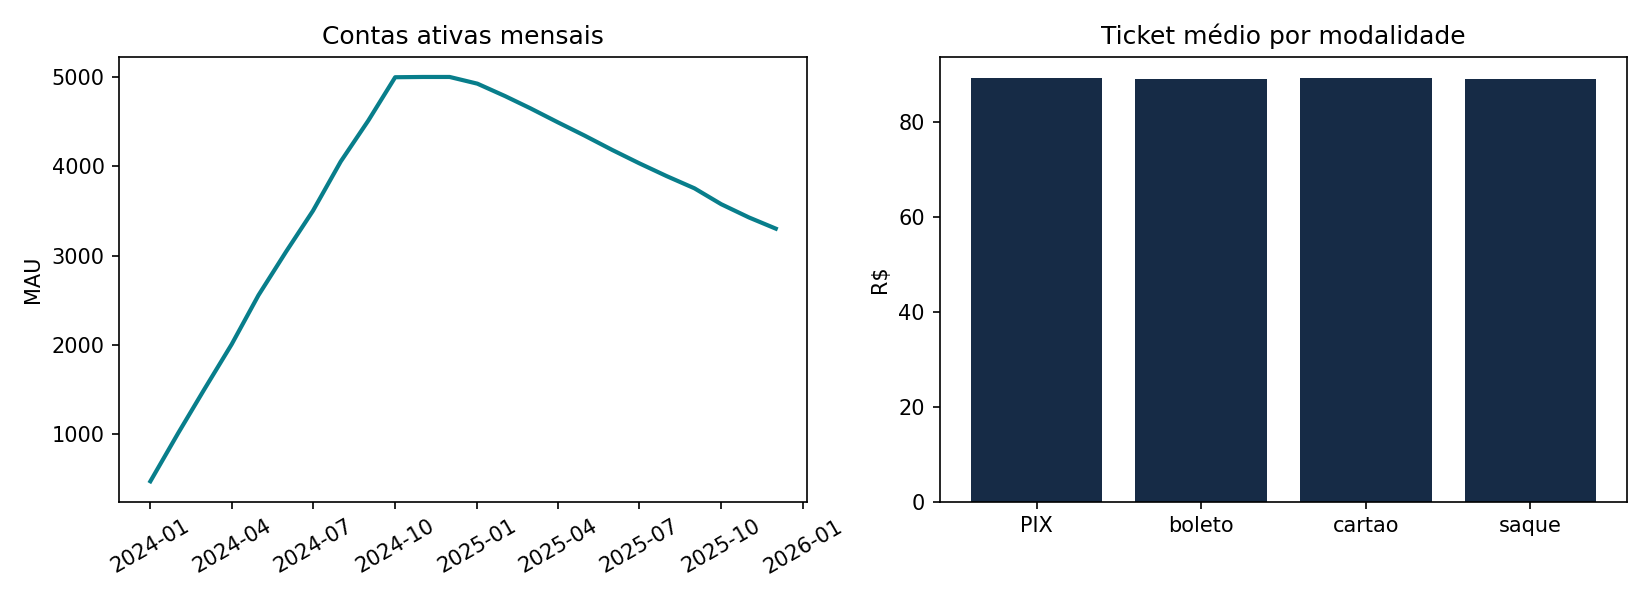

In [4]:
for name in ['mau', 'dau', 'ticket']:
    display(pd.read_csv(REPORTS / f'sql_{name}.csv').tail())
display(Image(filename=str(FIGURES / 'executive.png')))

## Leitura crítica

Welch testa diferença no ticket médio por conta entre segmentos; qui-quadrado testa associação entre segmento e inatividade no encerramento. IC t de 95% refere-se à média dos tickets por conta, não ao ticket ponderado por transação. Os segmentos são sorteados sem efeito causal; um p-valor pequeno isolado não comprova impacto. São análises exploratórias sem correção por múltiplas comparações.